<a href="https://colab.research.google.com/github/AlanAmaro13/fruit-classifier10/blob/main/0_DataAcquisition_PreProcessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Fruit Classification Dataset - Data Acquisition & Preprocessing

This notebook serves as the foundational preprocessing pipeline for the Fruit Classification project. It handles the complete data preparation workflow: downloading the 10-class fruit dataset from Kaggle, performing exploratory analysis on image resolutions and class distributions, standardizing all images to 128×128 pixels, normalizing pixel values to the [0,1] range, and creating stratified train/validation/test splits that preserve class balance across all subsets. The processed data is exported as numpy arrays, ready to be used for training deep learning models. This pipeline ensures data consistency, reproducibility, and optimal preparation for the subsequent modeling stages.


## Data Acquisiton and Pre-Processing

## Used libraries

In [ ]:
import os
import glob
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
from collections import Counter
import numpy as np
import cv2
from tqdm.notebook import tqdm

## Seaborn

In [ ]:
# Set style first
sns.set_style("whitegrid")

# Then customize individual elements through rcParams
plt.rcParams.update({
   "figure.dpi": 300,           # Default DPI for new figures
   "savefig.dpi": 300,          # DPI when saving figures

   # Font settings
   "font.family": "sans-serif",     # Universal font family
   "font.size": 11,                   # Base font size

   # Title and label sizes
   "axes.titlesize": 16,             # Axis title size
   "axes.titleweight": "bold",       # Axis title weight
   "axes.labelsize": 14,             # Axis label size
   "axes.labelweight": "semibold",   # Axis label weight

   # -------------------------------------------------

   # Tick LABEL sizes (text next to ticks)
   "xtick.labelsize": 11,       # Size of x-axis tick labels (e.g., "0", "1", "2")
   "ytick.labelsize": 11,       # Size of y-axis tick labels

   # Tick MARK sizes (physical marks on axes)
   "xtick.major.size": 6,       # Length of MAJOR tick marks on x-axis
   "ytick.major.size": 6,       # Length of MAJOR tick marks on y-axis

   # Additional tick parameters you might want to use:
   "xtick.minor.size": 3,       # Length of MINOR tick marks on x-axis
   "ytick.minor.size": 3,       # Length of MINOR tick marks on y-axis

   # Tick WIDTH (thickness)
   "xtick.major.width": 1,      # Width/Thickness of major ticks
   "ytick.major.width": 1,      # Width/Thickness of major ticks

   # Tick PADDING (distance from label to tick)
   "xtick.major.pad": 3.5,      # Padding between x-tick and label
   "ytick.major.pad": 3.5,      # Padding between y-tick and label

   # Tick DIRECTIONS
   "xtick.direction": "out",    # "in", "out", or "inout"
   "ytick.direction": "out",    # Points outward from axis

   # Tick COLORS
   "xtick.color": "black",      # Color of x-axis ticks and labels
   "ytick.color": "black",      # Color of y-axis ticks and labels

   # MINOR ticks (for more granular scales)
   "xtick.minor.visible": False,  # Show minor x-ticks
   "ytick.minor.visible": False,  # Show minor y-ticks

   # BOTTOM/TOP/LEFT/RIGHT ticks (which sides get ticks)
   "xtick.top": False,          # Show ticks on top of plot
   "xtick.bottom": True,        # Show ticks on bottom (default: True)
   "ytick.left": True,          # Show ticks on left (default: True)
   "ytick.right": False,        # Show ticks on right

   # ---------------------------------

   # Legend
   "legend.fontsize": 10,
   "legend.title_fontsize": 12,
   "legend.framealpha":0.9,

   # Figure title (for suptitle)
   "figure.titlesize": 18,
   "figure.titleweight": "bold",

   # ----------------------------------

   # Figure border
   #"figure.edgecolor": "black",
   #"figure.frameon": True,
   #"figure.linewidth": 2.0,

   # Axes borders (spines)
   "axes.linewidth": 1.0,           # Width of axis lines
   "axes.edgecolor": "black",       # Color of axis lines

   # Individual spine control via rcParams
   "axes.spines.top": True,
   "axes.spines.bottom": True,
   "axes.spines.left": True,
   "axes.spines.right": True,

   # ----------------------------
   # Patch properties (for histograms, bars, kde fills, etc.)
   "patch.linewidth": 1.5,           # Default linewidth for patches
   "patch.edgecolor": "black",       # Default edge color
   "patch.facecolor": "blue",        # Default fill color (careful with this!)
   "patch.force_edgecolor": True,    # Always show edges

})


## Get the Data

The first step is to download the data from the Kaggle repository. We used the following commands (given by Kaggle) to get the data.

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download(
    "karimabdulnabi/fruit-classification10-class",
    )

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'fruit-classification10-class' dataset.
Path to dataset files: /kaggle/input/fruit-classification10-class


To visualize the data scheme we use the following function to visualize all sub-folders in a tree format.

In [ ]:
def list_folders_tree(path, prefix=''):
    """List folders in a tree-like format"""
    try:
        # Get all items in the directory
        items = sorted([item for item in os.listdir(path)
                       if os.path.isdir(os.path.join(path, item))])

        for i, item in enumerate(items):
            is_last = i == len(items) - 1
            current_prefix = '└── ' if is_last else '├── '
            print(prefix + current_prefix + item)

            # Recursively list subfolders
            subfolder_path = os.path.join(path, item)
            new_prefix = prefix + ('    ' if is_last else '│   ')
            list_folders_tree(subfolder_path, new_prefix)

    except PermissionError:
        print(prefix + "└── [Permission Denied]")
    except FileNotFoundError:
        print(f"Path not found: {path}")

In [ ]:
list_folders_tree('/root/.cache/kagglehub/datasets/karimabdulnabi/fruit-classification10-class/versions/1')

└── MY_data
    ├── predict
    ├── test
    │   ├── apple
    │   ├── avocado
    │   ├── banana
    │   ├── cherry
    │   ├── kiwi
    │   ├── mango
    │   ├── orange
    │   ├── pinenapple
    │   ├── stawberries
    │   └── watermelon
    └── train
        ├── Apple
        ├── Banana
        ├── avocado
        ├── cherry
        ├── kiwi
        ├── mango
        ├── orange
        ├── pinenapple
        ├── strawberries
        └── watermelon


In [ ]:
os.listdir('/root/.cache/kagglehub/datasets/karimabdulnabi/fruit-classification10-class/versions/1/MY_data/train/kiwi')[:5]

['img_1921.jpeg',
 'img_3751.jpeg',
 'img_4141.jpeg',
 'img_2661.jpeg',
 'img_4201.jpeg']

### Path & Extensions

Our data is in _.jpeg_ format. Let's create a function to get the paths of all files in our dataset.

In [ ]:
def get_all_files_glob(folder_path, pattern='*'):
    """
    Get all file paths recursively using glob

    Args:
        folder_path: Root folder to search
        pattern: File pattern to match (default: '*')

    Returns:
        List of file paths
    """
    # Using ** for recursive search
    search_pattern = os.path.join(folder_path, '**', pattern)
    files = glob.glob(search_pattern, recursive=True)

    # Filter to only files (not directories)
    files = [f for f in files if os.path.isfile(f)]

    return files

In [ ]:
all_paths_dataset = get_all_files_glob('/root/.cache/kagglehub/datasets/karimabdulnabi/fruit-classification10-class/versions/1/MY_data/')

The following number of elements is in _good agrement_ with the information provided by Kaggle.

In [ ]:
len(all_paths_dataset)

3374

In [ ]:
all_paths_dataset[:5]

['/root/.cache/kagglehub/datasets/karimabdulnabi/fruit-classification10-class/versions/1/MY_data/predict/0122.jpeg',
 '/root/.cache/kagglehub/datasets/karimabdulnabi/fruit-classification10-class/versions/1/MY_data/predict/img_241.jpeg',
 '/root/.cache/kagglehub/datasets/karimabdulnabi/fruit-classification10-class/versions/1/MY_data/predict/365.jpeg',
 '/root/.cache/kagglehub/datasets/karimabdulnabi/fruit-classification10-class/versions/1/MY_data/predict/img_411.jpeg',
 '/root/.cache/kagglehub/datasets/karimabdulnabi/fruit-classification10-class/versions/1/MY_data/predict/99.jpeg']

We have all the paths, let's make a function to get statistics about the extension format to answer the question _What kind of files do we have?_

In [ ]:
extensions = [os.path.splitext(f)[1] for f in all_paths_dataset]
set(extensions)

{'.jpeg'}

1. **All of our files are _.jpeg_**

## Read Image

Let's make a function to read all the images and get their dimensions.

In [ ]:
def read_image_matplotlib(image_path):
    """
    Read an image using matplotlib and get its dimensions

    Args:
        image_path: Path to the image file

    Returns:
        tuple: (image_array, dimensions_string)
    """
    try:
        # Read image
        img = plt.imread(image_path)

        # Get dimensions
        if len(img.shape) == 3:
            height, width, channels = img.shape
            dims_string = f"{width}x{height}"
        else:  # Grayscale
            height, width = img.shape
            dims_string = f"{width}x{height}"

        return img, dims_string

    except Exception as e:
        print(f"Error reading {image_path}: {e}")
        return None, None


Let's get all the resolutions

In [ ]:
resolutions = [ read_image_matplotlib(x)[1] for x in all_paths_dataset  ]

## Resolution Distribution

Let's list all the available resolutions in our dataset:

In [ ]:
len(list(set(resolutions)))

288

As we have so different resolutions, let's standarize the resolution to just one format _which resolution is the most common?_

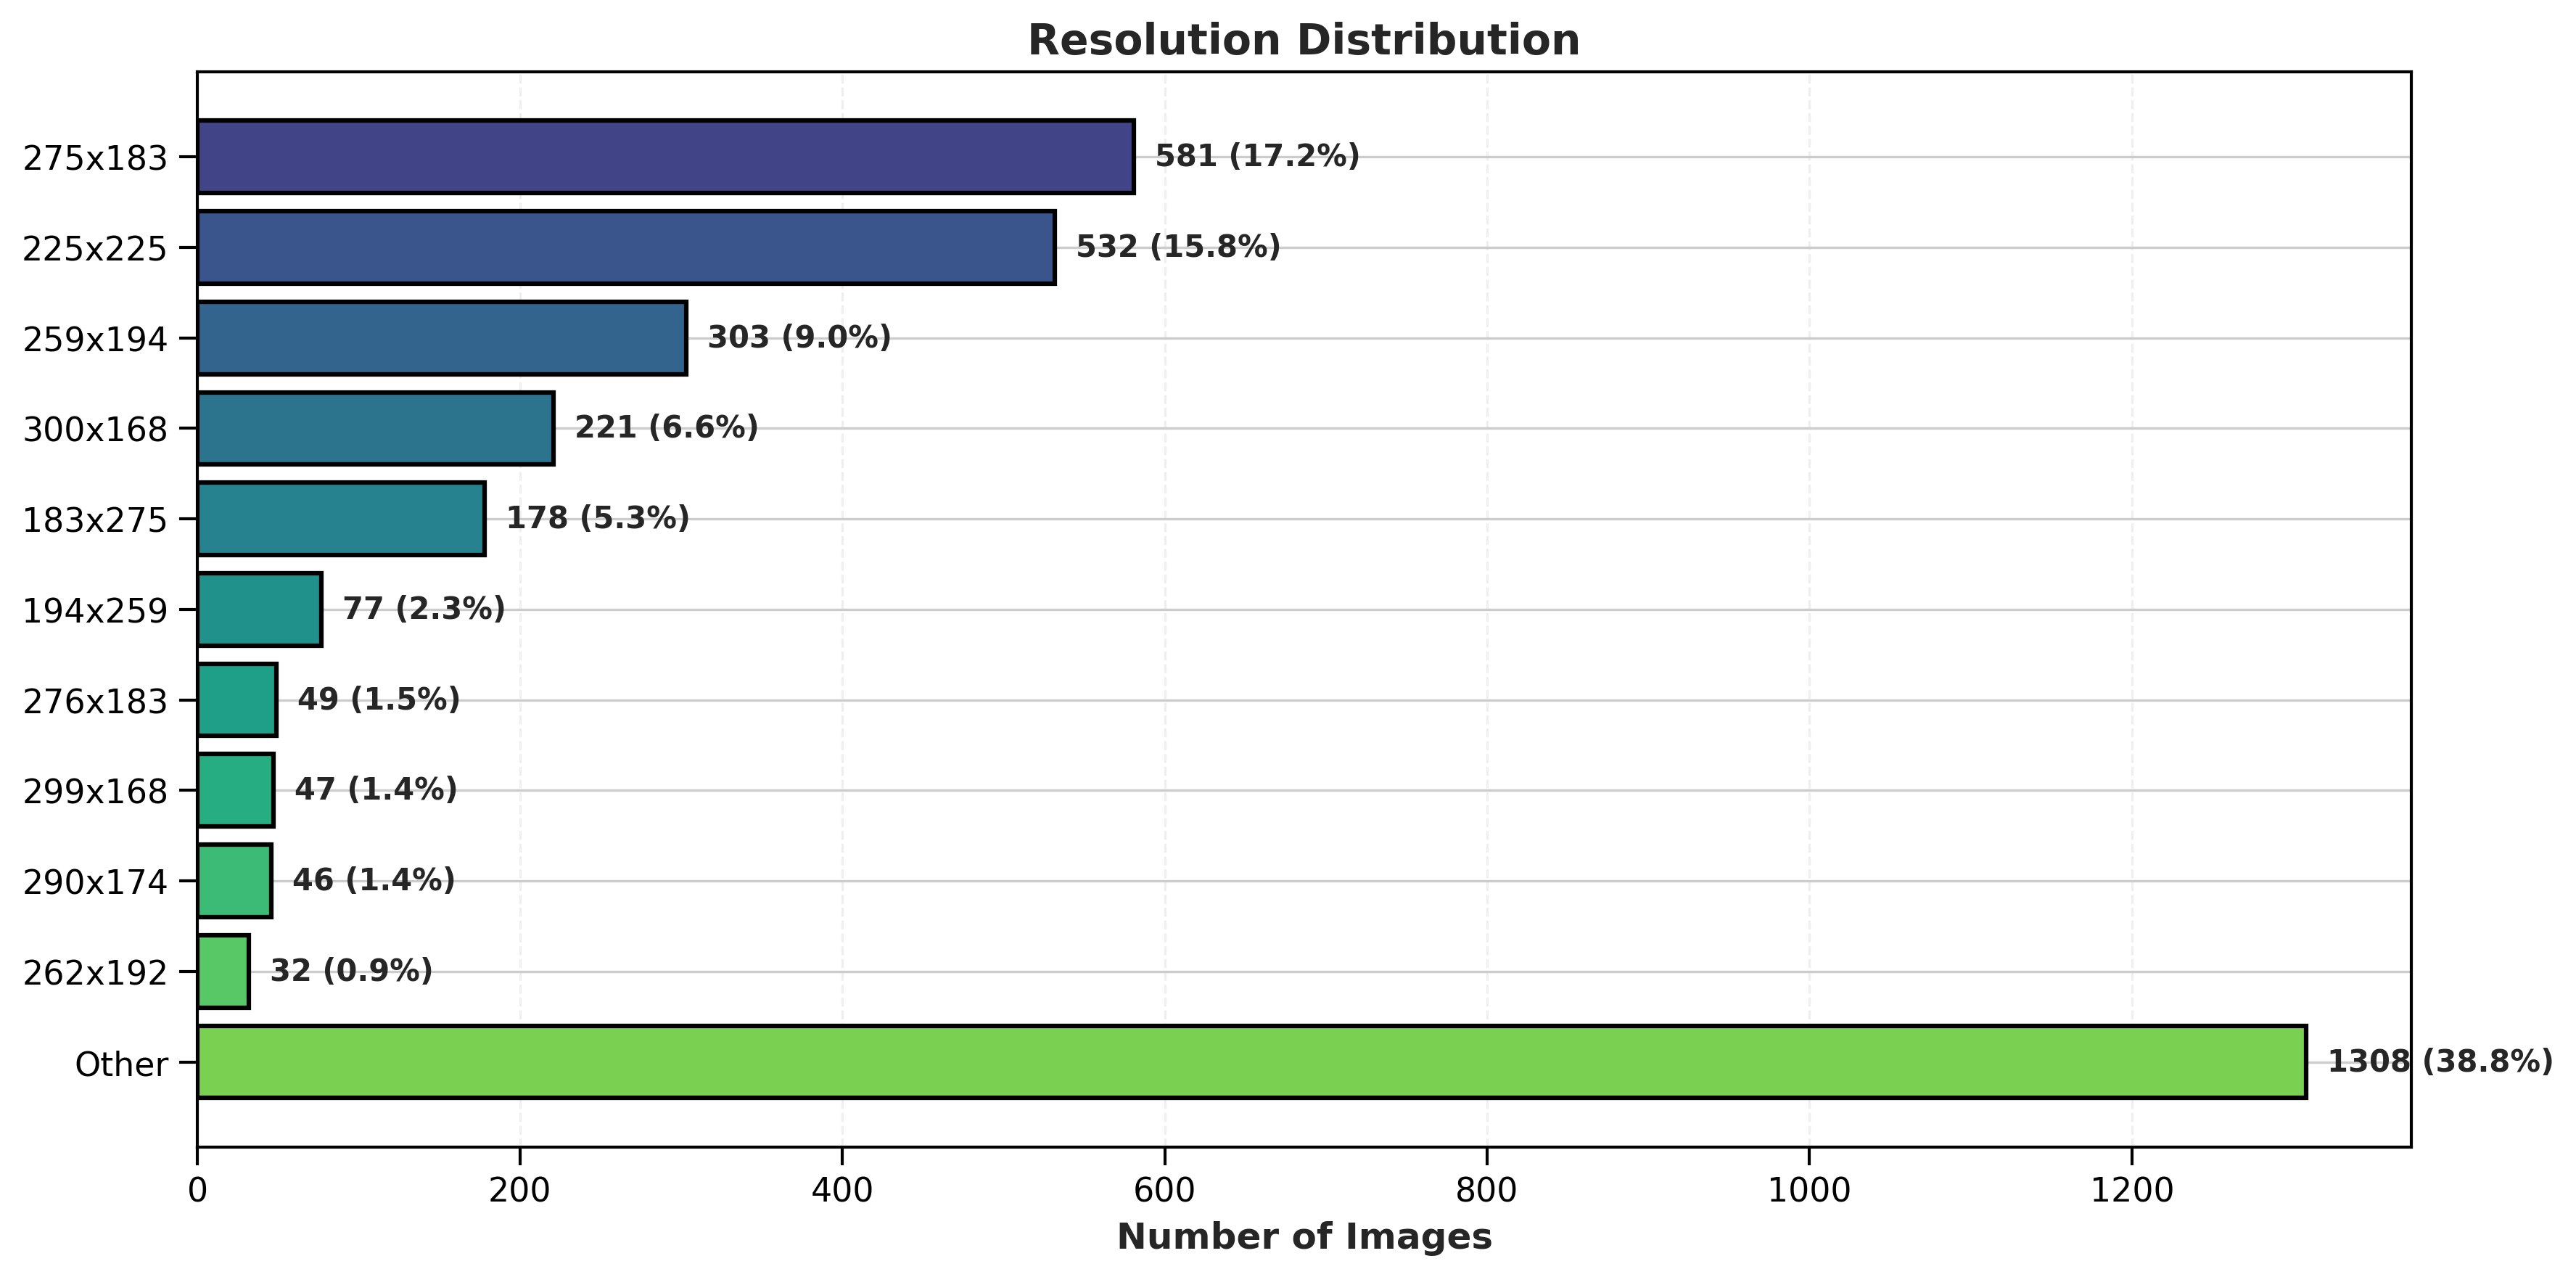

Total images: 3374
Unique resolutions: 288

Top 5 resolutions:
  275x183: 581 (17.2%)
  225x225: 532 (15.8%)
  259x194: 303 (9.0%)
  300x168: 221 (6.6%)
  183x275: 178 (5.3%)


In [ ]:
def plot_resolution_distribution_advanced(resolutions, title="Resolution Distribution",
                                         top_n=None, show_percentages=True):
    """
    Advanced horizontal bar plot with percentages and styling
    """
    # Count frequencies
    resolution_counts = Counter(resolutions)
    total = len(resolutions)

    # Sort and optionally limit to top N
    sorted_resolutions = sorted(resolution_counts.items(), key=lambda x: x[1], reverse=True)

    if top_n:
        sorted_resolutions = sorted_resolutions[:top_n]
        other_count = total - sum(count for _, count in sorted_resolutions)
        if other_count > 0:
            sorted_resolutions.append(('Other', other_count))

    labels, counts = zip(*sorted_resolutions)

    # Calculate percentages
    percentages = [count/total * 100 for count in counts]

    # Create plot
    fig, ax = plt.subplots(figsize=(12, max(6, len(labels)*0.4)))
    y_pos = np.arange(len(labels))

    # Create bars with colormap
    colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(labels)))
    bars = ax.barh(y_pos, counts, color=colors)

    # Customize
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels)
    ax.set_xlabel('Number of Images', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.invert_yaxis()  # Most common at top

    # Add value labels
    for i, (bar, count, pct) in enumerate(zip(bars, counts, percentages)):
        if show_percentages:
            label = f'{count} ({pct:.1f}%)'
        else:
            label = str(count)

        ax.text(count + (max(counts)*0.01), bar.get_y() + bar.get_height()/2,
                label, va='center', ha='left', fontweight='bold', fontsize=10)

    # Add grid for better readability
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)

    plt.tight_layout()
    plt.show()

    # Print summary
    print(f"Total images: {total}")
    print(f"Unique resolutions: {len(resolution_counts)}")
    print(f"\nTop 5 resolutions:")
    for label, count in sorted_resolutions[:5]:
        print(f"  {label}: {count} ({count/total*100:.1f}%)")

    return resolution_counts

_ = plot_resolution_distribution_advanced(resolutions, top_n=10)

As the previous result suggests the resolution across the dataset is no-uniform. Almost 20% of the data corresponds to the 275x183 resolutions. To standarize it let's fix it to 128x128 to increase the speed of the computations.


First, let's load all the images:

## Resize images

In [ ]:
images = [ read_image_matplotlib(x)[0] for x in all_paths_dataset  ]

array([[[ 84, 113,   0],
        [154, 169,  88],
        [187, 193, 131],
        ...,
        [122, 159,   2],
        [123, 160,   3],
        [118, 153,   1]],

       [[ 92, 117,  15],
        [155, 166,  97],
        [184, 189, 135],
        ...,
        [121, 158,   3],
        [123, 160,   5],
        [118, 153,   1]],

       [[109, 127,  45],
        [155, 159, 108],
        [176, 174, 135],
        ...,
        [118, 157,   2],
        [120, 159,   4],
        [118, 153,   1]],

       ...,

       [[213, 197, 161],
        [214, 198, 162],
        [215, 199, 163],
        ...,
        [165, 168, 139],
        [165, 168, 139],
        [159, 162, 141]],

       [[215, 197, 159],
        [215, 197, 159],
        [216, 198, 160],
        ...,
        [171, 173, 149],
        [171, 173, 149],
        [161, 167, 141]],

       [[215, 192, 151],
        [215, 192, 151],
        [216, 193, 152],
        ...,
        [178, 184, 150],
        [177, 182, 150],
        [169, 174, 144]]], dtype=uint8)
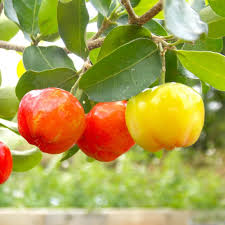

In [ ]:
images[3000]

In [ ]:
images[0].shape

(183, 275, 3)

Using the following function we are going to standarize the resolution to 128x128.

In [ ]:
def resize_images_opencv(image_paths, output_size=(128, 128), output_dir=None):
    """
    Resize images using OpenCV

    Args:
        image_paths: List of image
        output_size: Target size (width, height)
        output_dir: Directory to save resized images (if None, returns arrays)

    Returns:
        List of resized image arrays or saves them to disk
    """
    resized_images = []

    for img in tqdm(image_paths, desc="Resizing images"):
        # Read image
        #img = cv2.imread(img_path)

        if img is not None:
            # Convert BGR to RGB
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            # Resize
            img_resized = cv2.resize(img, output_size, interpolation=cv2.INTER_AREA)

            img_resized = cv2.cvtColor(img_resized, cv2.COLOR_RGB2BGR)

            resized_images.append(img_resized)

    return np.array(resized_images)

Our images are in the scale 0 to 255. Let's normalize to 0 and 1.

In [ ]:
np.min(images[0]), np.max(images[0])

(np.uint8(0), np.uint8(255))

In [ ]:
resize_images = resize_images_opencv(images)/255.0

Resizing images:   0%|          | 0/3374 [00:00<?, ?it/s]

Our dataset of images has now 3,374 images with the resolution of 128x128 in RGB denoted as 3 Channels.

In [ ]:
resize_images.shape

(3374, 128, 128, 3)

Let's visualize our rescaled images:

## Visualization

In [ ]:
def show_image(img_array, title=None, figsize=(5, 5)):
    """
    Display a single image from numpy array

    Args:
        img_array: numpy array of shape (height, width, channels) or (height, width)
        title: Optional title for the image
        figsize: Figure size (width, height) in inches
    """
    plt.figure(figsize=figsize)

    # Check if image is normalized (0-1) or not (0-255)
    if img_array.max() <= 1.0 and img_array.min() >= 0:
        # Already normalized
        plt.imshow(img_array)
    else:
        # Assume 0-255 range, clip to valid range
        plt.imshow(np.clip(img_array, 0, 255).astype(np.uint8))

    plt.axis('off')
    if title:
        plt.title(title)
    plt.tight_layout()
    plt.show()

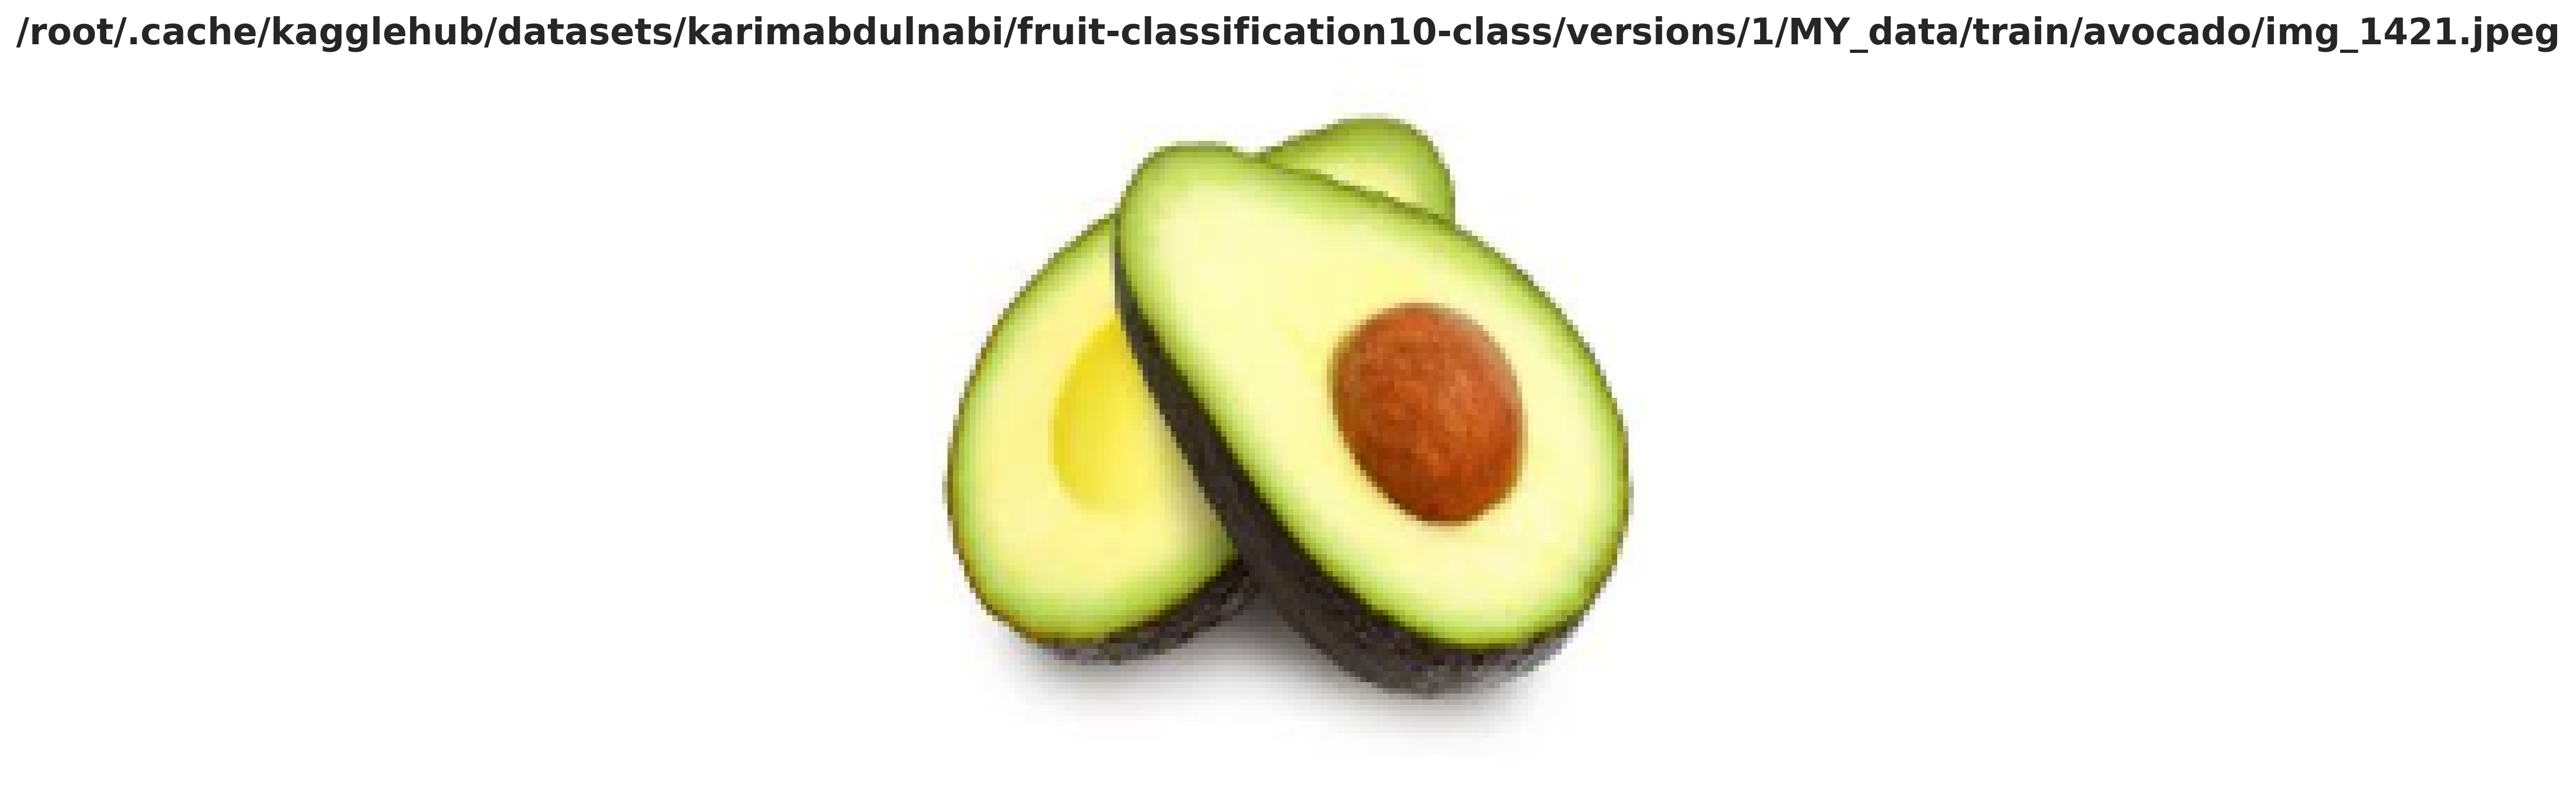

In [ ]:
i = 1234
show_image(resize_images[i], title=all_paths_dataset[i])

In [ ]:
resize_images.shape

(3374, 128, 128, 3)

Now, let's get only the paths related to the train and test set. Let's ignore the preds set as it only contains a small number of samples and it'd be more difficult to classify given there's no label of the fruit.

In [ ]:
train_test_indexes = [ (('train' in x) or ('test' in x) ) for x in all_paths_dataset ]

Let's select the images of the train and test test and merge them into just one set.

In [ ]:
image_data = resize_images[train_test_indexes]
image_data.shape

(3326, 128, 128, 3)

We do the same for the labels, let's select just the corresponding to the train and test set.

In [ ]:
train_test_labels = np.array(all_paths_dataset)[train_test_indexes]

And using the next list comprehension let's get the fruit label.

In [ ]:
labels = np.array([ x.split('/')[-2].lower() for x in train_test_labels])

* We observer some _misclassified classes_, as Bananas and bananas, and also stawberries and strawberries. The first issue is solved with the method _lower()_.

While the second one is solved getting the indexes and changing the label to the right one.

In [ ]:
strawberry_indexes = np.where(labels == 'stawberries')
strawberry_indexes[0].shape

(103,)

In [ ]:
labels[strawberry_indexes] = 'strawberries'

In [ ]:
labels

array(['strawberries', 'strawberries', 'strawberries', ..., 'mango',
       'mango', 'mango'], dtype='<U12')

In [ ]:
labels.shape

(3326,)

## Class Distribution

Let's consider our classes distribution.

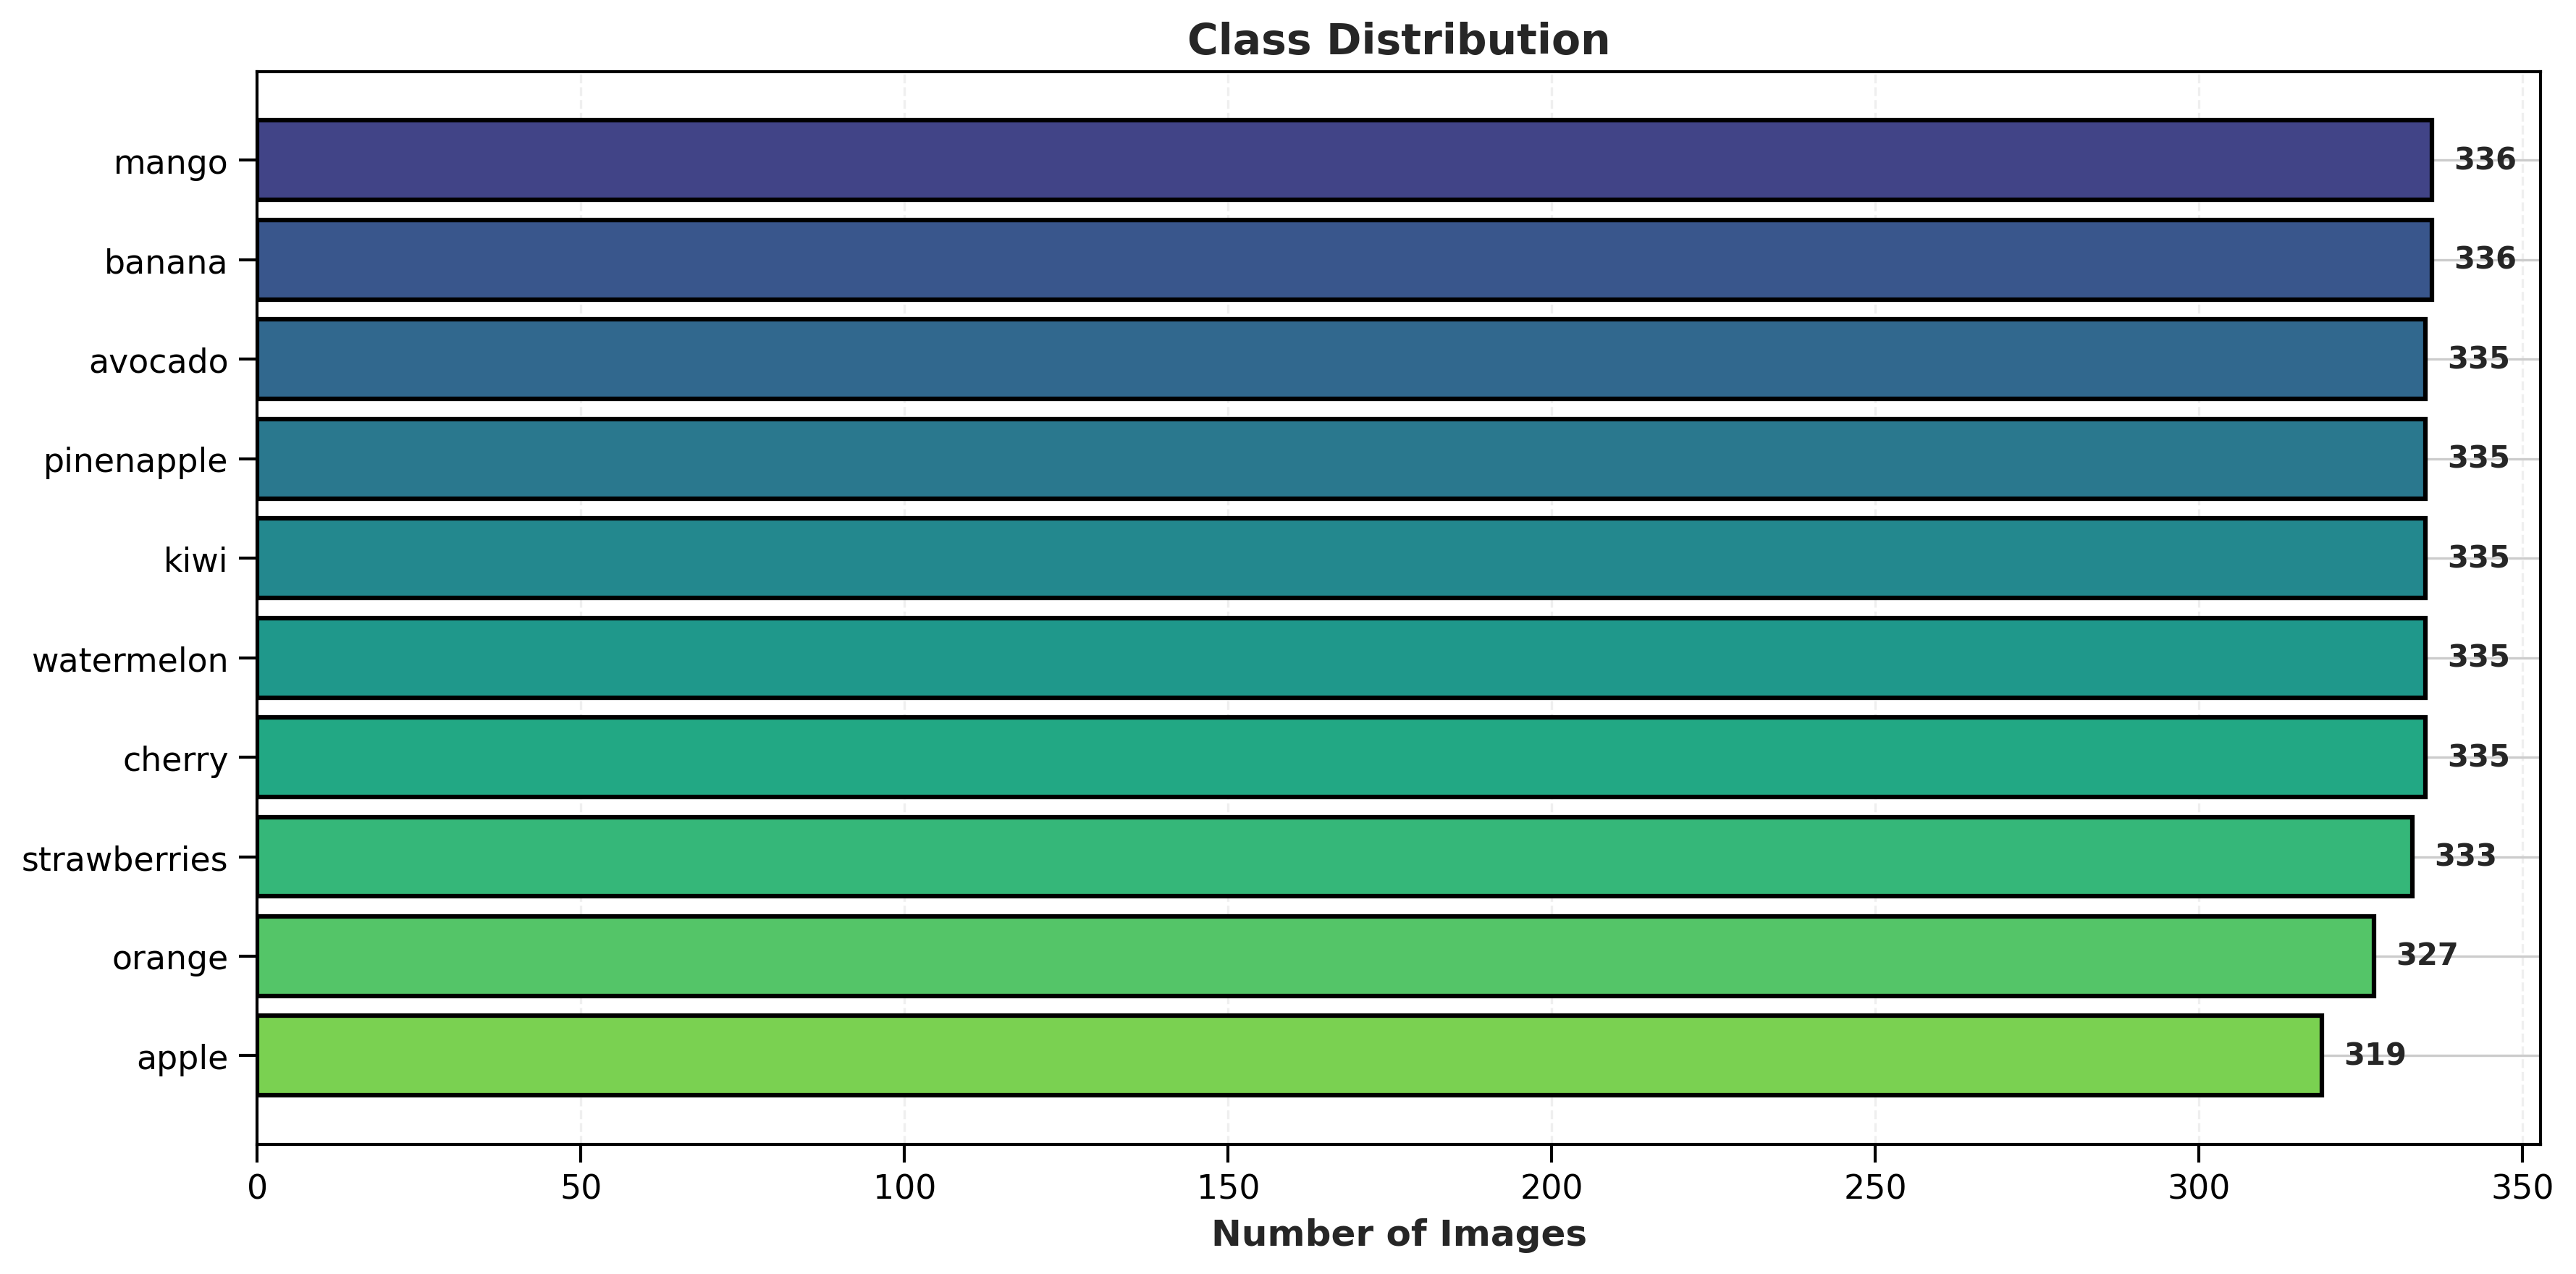

Total images: 3326
Unique resolutions: 10

Top 5 resolutions:
  mango: 336 (10.1%)
  banana: 336 (10.1%)
  avocado: 335 (10.1%)
  pinenapple: 335 (10.1%)
  kiwi: 335 (10.1%)


Counter({np.str_('strawberries'): 333,
         np.str_('avocado'): 335,
         np.str_('orange'): 327,
         np.str_('pinenapple'): 335,
         np.str_('kiwi'): 335,
         np.str_('watermelon'): 335,
         np.str_('cherry'): 335,
         np.str_('mango'): 336,
         np.str_('banana'): 336,
         np.str_('apple'): 319})

In [ ]:
plot_resolution_distribution_advanced(labels, top_n=10, title = 'Class Distribution', show_percentages= False)

## Final Dimensions

Let's observe our final dimensions:

In [ ]:
image_data.shape

(3326, 128, 128, 3)

In [ ]:
labels.shape

(3326,)

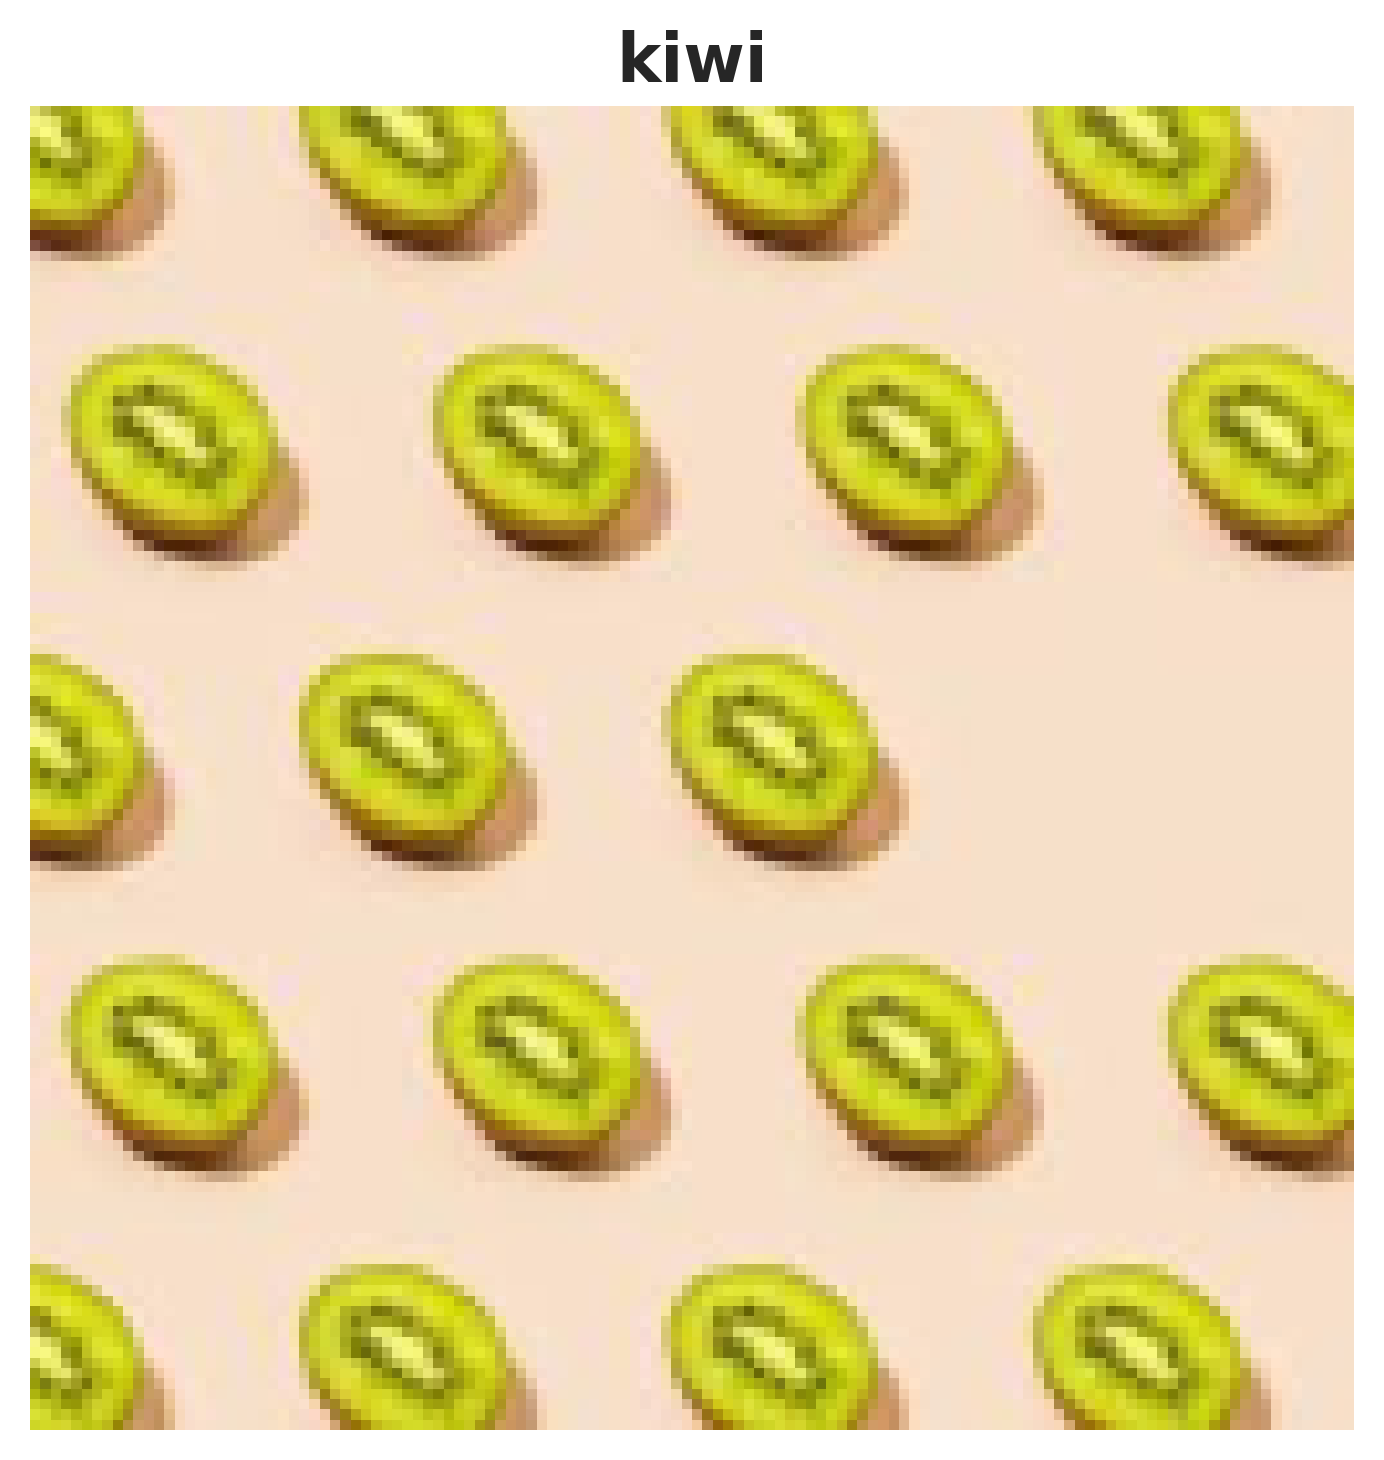

In [ ]:
i = 412
show_image(image_data[i], title=labels[i])

## Spliting the data using Stratified Sampling

Let's create the Train, Test and Validation sets with same number of elements per class. This kind of split is denominated as Stratified Sampling.

In [ ]:
from sklearn.model_selection import train_test_split

def split_dataset_stratified(X, y, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15,
                            random_state=42, show_stats=True, class_names=None):
    """
    Complete stratified split with statistics and visualization

    Args:
        X: Features array
        y: Labels array
        train_ratio: Proportion for training
        val_ratio: Proportion for validation
        test_ratio: Proportion for testing
        random_state: Random seed
        show_stats: Show distribution statistics
        class_names: List of class names for visualization

    Returns:
        Dictionary containing splits and metadata
    """

    # Validate ratios
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-10, "Ratios must sum to 1"

    # First split: separate test set
    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y,
        test_size=test_ratio,
        stratify=y,
        random_state=random_state,
        shuffle=True
    )

    # Second split: separate train and validation
    # Adjust validation ratio relative to remaining data
    relative_val_ratio = val_ratio / (train_ratio + val_ratio)

    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp,
        test_size=relative_val_ratio,
        stratify=y_temp,
        random_state=random_state,
        shuffle=True
    )

    # Create result dictionary
    result = {
        'X_train': X_train, 'y_train': y_train,
        'X_val': X_val, 'y_val': y_val,
        'X_test': X_test, 'y_test': y_test,
        'metadata': {
            'total_samples': len(X),
            'train_samples': len(X_train),
            'val_samples': len(X_val),
            'test_samples': len(X_test),
            'train_ratio': len(X_train)/len(X),
            'val_ratio': len(X_val)/len(X),
            'test_ratio': len(X_test)/len(X),
            'n_classes': len(np.unique(y))
        }
    }

    if show_stats:
        display_split_statistics(result, class_names)

    return result

def display_split_statistics(splits, class_names=None):
    """
    Display detailed statistics about the split
    """
    y_train = splits['y_train']
    y_val = splits['y_val']
    y_test = splits['y_test']
    metadata = splits['metadata']

    print("="*60)
    print("DATASET SPLIT SUMMARY")
    print("="*60)
    print(f"Total samples: {metadata['total_samples']}")
    print(f"Number of classes: {metadata['n_classes']}")
    print("\nSplit sizes:")
    print(f"  Train: {metadata['train_samples']} ({metadata['train_ratio']*100:.1f}%)")
    print(f"  Validation: {metadata['val_samples']} ({metadata['val_ratio']*100:.1f}%)")
    print(f"  Test: {metadata['test_samples']} ({metadata['test_ratio']*100:.1f}%)")

    # Class distribution
    print("\n" + "="*60)
    print("CLASS DISTRIBUTION")
    print("="*60)

    # Get unique classes
    all_classes = np.unique(np.concatenate([y_train, y_val, y_test]))

    # Prepare data for visualization
    class_counts = []
    class_names_list = []

    for i, class_id in enumerate(sorted(all_classes)):
        train_count = np.sum(y_train == class_id)
        val_count = np.sum(y_val == class_id)
        test_count = np.sum(y_test == class_id)
        total = train_count + val_count + test_count

        class_label = class_names[class_id] if class_names else f"Class {class_id}"
        class_names_list.append(class_label)
        class_counts.append([train_count, val_count, test_count])

        print(f"\n{class_label}:")
        print(f"  Train: {train_count} ({train_count/total*100:.1f}%)")
        print(f"  Val:   {val_count} ({val_count/total*100:.1f}%)")
        print(f"  Test:  {test_count} ({test_count/total*100:.1f}%)")
        print(f"  Total: {total}")

    # Visualize distribution
    visualize_split_distribution(class_names_list, class_counts)

def visualize_split_distribution(class_names, class_counts):
    """
    Visualize the class distribution across splits
    """
    class_counts = np.array(class_counts)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    # Stacked bar chart
    x = np.arange(len(class_names))
    width = 0.8

    bottom = np.zeros(len(class_names))
    colors = ['#2ecc71', '#f39c12', '#e74c3c']
    labels = ['Train', 'Validation', 'Test']

    for i, (counts, color, label) in enumerate(zip(class_counts.T, colors, labels)):
        ax1.bar(x, counts, width, bottom=bottom, label=label, color=color, alpha=0.8)
        bottom += counts

    ax1.set_xlabel('Classes')
    ax1.set_ylabel('Number of samples')
    ax1.set_title('Class Distribution Across Splits')
    ax1.set_xticks(x)
    ax1.set_xticklabels(class_names, rotation=45, ha='right')
    ax1.legend()
    ax1.grid(axis='y', alpha=0.3)

    # Pie chart of overall split
    total_counts = class_counts.sum(axis=0)
    ax2.pie(total_counts, labels=labels, autopct='%1.1f%%',
            colors=colors, startangle=90, explode=(0.05, 0.05, 0.05))
    ax2.set_title('Overall Split Distribution')

    plt.tight_layout()
    plt.show()

# Usage with your fruit dataset
def prepare_and_split_fruit_dataset(X, y, class_names=None, train_ratio=0.7, val_ratio=0.15):
    """
    Prepare and split your fruit dataset
    """
    print("Original data shapes:")
    print(f"  X: {X.shape}")
    print(f"  y: {y.shape}")
    print(f"  Classes: {np.unique(y)}")

    # Perform stratified split
    splits = split_dataset_stratified(
        X, y,
        train_ratio=train_ratio,
        val_ratio=val_ratio,
        test_ratio=1 - train_ratio - val_ratio,
        random_state=42,
        show_stats=True,
        class_names=class_names
    )

    return splits



Original data shapes:
  X: (3326, 128, 128, 3)
  y: (3326,)
  Classes: ['apple' 'avocado' 'banana' 'cherry' 'kiwi' 'mango' 'orange' 'pinenapple'
 'strawberries' 'watermelon']
DATASET SPLIT SUMMARY
Total samples: 3326
Number of classes: 10

Split sizes:
  Train: 2328 (70.0%)
  Validation: 499 (15.0%)
  Test: 499 (15.0%)

CLASS DISTRIBUTION

Class apple:
  Train: 223 (69.9%)
  Val:   48 (15.0%)
  Test:  48 (15.0%)
  Total: 319

Class avocado:
  Train: 235 (70.1%)
  Val:   50 (14.9%)
  Test:  50 (14.9%)
  Total: 335

Class banana:
  Train: 235 (69.9%)
  Val:   50 (14.9%)
  Test:  51 (15.2%)
  Total: 336

Class cherry:
  Train: 235 (70.1%)
  Val:   50 (14.9%)
  Test:  50 (14.9%)
  Total: 335

Class kiwi:
  Train: 234 (69.9%)
  Val:   51 (15.2%)
  Test:  50 (14.9%)
  Total: 335

Class mango:
  Train: 235 (69.9%)
  Val:   50 (14.9%)
  Test:  51 (15.2%)
  Total: 336

Class orange:
  Train: 229 (70.0%)
  Val:   49 (15.0%)
  Test:  49 (15.0%)
  Total: 327

Class pinenapple:
  Train: 235 (70.1%)

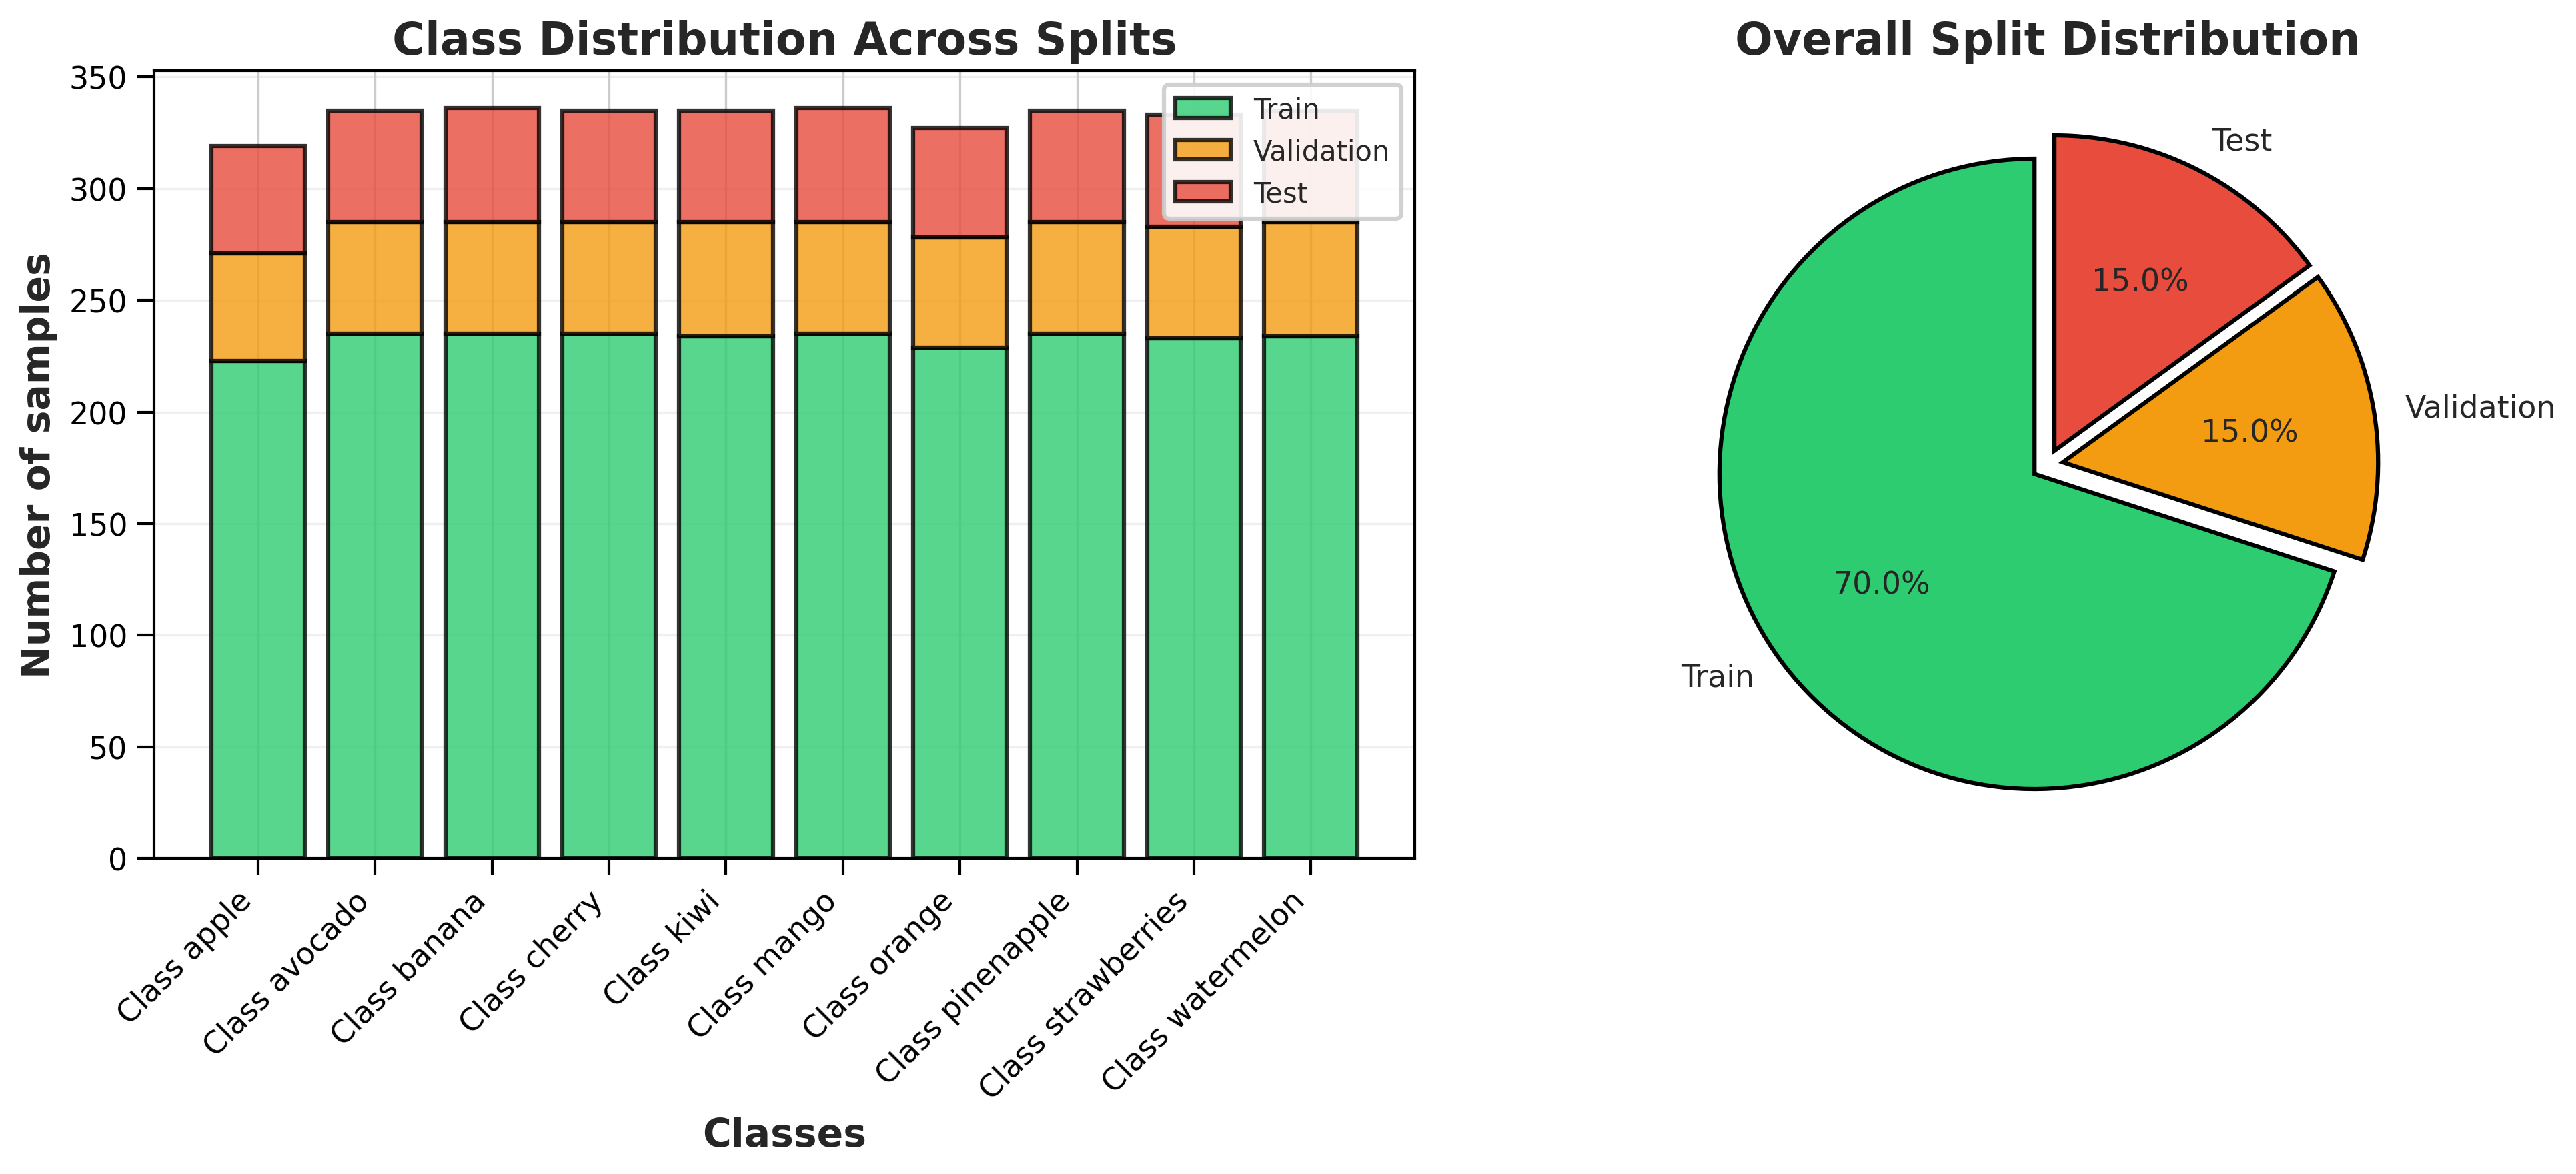

In [ ]:
splits = prepare_and_split_fruit_dataset(image_data, labels)


In [ ]:
X_train, y_train = splits['X_train'], splits['y_train']
X_val, y_val = splits['X_val'], splits['y_val']
X_test, y_test = splits['X_test'], splits['y_test']

## Save the database

Save the sets as numpy arrays.

In [ ]:
np.save('/content/drive/MyDrive/cellularAutomata/fruit_classification/database/x_train', X_train)
np.save('/content/drive/MyDrive/cellularAutomata/fruit_classification/database/x_test', X_test)
np.save('/content/drive/MyDrive/cellularAutomata/fruit_classification/database/x_val', X_val)

In [ ]:
np.save('/content/drive/MyDrive/cellularAutomata/fruit_classification/database/y_train', y_train)
np.save('/content/drive/MyDrive/cellularAutomata/fruit_classification/database/y_test', y_test)
np.save('/content/drive/MyDrive/cellularAutomata/fruit_classification/database/y_val', y_val)